<a href="https://colab.research.google.com/github/ThomasAlbin/Space-Science-With-Python/blob/main/2026/01_SPICE_reference_frames.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPICE Lecture 01: Reference Frames

In this notebook, we will dive into **Reference Frames**, coordinate systems, and transformations in SPICE! 

### What is a Reference Frame?
A coordinate system with a particular reference (J2000, ECLIPJ2000, custom kernels) is used to identify the positions and velocities of objects in space. In SPICE, reference frames are classified into two major categories:
1. **Inertial Frames:** These are non-rotating, non-accelerating frames fixed with respect to distant stars (e.g., `J2000` which is Earth-equator based, and `ECLIPJ2000` which is Earth-ecliptic based).
2. **Non-Inertial / Body-Fixed Frames:** These are rotating frames tied to a celestial body's surface (e.g., `IAU_EARTH`, `IAU_SATURN`, `IAU_SUN`). Coordinate values change over time as the body rotates.

### What Kernels Do We Need?
In the previous notebook, we loaded a **Leapseconds Kernel (LSK)** (`.tls`). For reference frames, we will load two additional kernel types:
- **Planetary Constants Kernel (PCK)** (`.tpc`): Stores size, shape, and orientation characteristics of solar system bodies. Necessary for body-fixed frames like `IAU_EARTH`.
- **Ephemeris Kernel (SPK)** (`.bsp`): Stores positions and velocities (states) of celestial bodies over time. Essential for tracking planetary orbits (e.g., Earth around the Sun).

*Please note: we cover astrodynamics and SPKs in detail in script number 02*

In [7]:
import spiceypy as spice
import numpy as np
import matplotlib.pyplot as plt

# Apply professional astronomical dark styles
plt.style.use('dark_background')
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 11

## 1. Downloading and Loading Kernels

We will download:
- Leapseconds (`naif0012.tls`)
- PCK (`pck00010.tpc`) for planetary rotational constants
- SPK (`de432s.bsp`) which is a short ephemeris kernel covering 1950 to 2050 for the planets and Sun.

In [ ]:
from pathlib import Path
import urllib.request

data_dir = Path("../data")
data_dir.mkdir(exist_ok=True)

# Define urls kernels
kernels = {
    "naif0012.tls": "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/naif0012.tls",
    "pck00010.tpc": "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/pck00010.tpc",
    "de432s.bsp": "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de432s.bsp"
}

# Download kernels if not already present
for name, url in kernels.items():
    path = data_dir / name
    if not path.exists():
        print(f"Downloading {name}...")
        urllib.request.urlretrieve(url, path)
    else:
        print(f"{name} already exists.")

# Load all downloaded kernels in SPICE
for name in kernels.keys():
    spice.furnsh(str(data_dir / name))

naif0012.tls already exists.
pck00010.tpc already exists.
de432s.bsp already exists.


## 2. Dynamic Rotating Frames: Transforming Coordinates with `pxform`

Body-fixed frames like `IAU_EARTH` rotate with the planet. To transform coordinate positions between a rotating frame and an inertial frame (like `J2000`), we use:
`spice.pxform(from_frame, to_frame, et)`

This returns a $3 \times 3$ rotation matrix at the epoch `et`. Let's define a fixed point on Earth's equator located on the Prime Meridian ($0^\circ$ latitude, $0^\circ$ longitude):
$$\vec{v}_{\text{fixed}} = [6378.1, 0, 0] \text{ km}$$

We will track how this coordinate rotates in the inertial `J2000` frame over a 24-hour period.

*Please note: when handling state vectors, we have a 6 dimensional vector that contains also the velcocity information / components of an object. In this case, we use the SPICE function sxform*

In [ ]:
# Equatorial point coordinate on the Earth's surface (Prime Meridian)
# Note, we use the Earth's equatorial radius in kilometers from Wikipedia. We could also extract the radius from a PCK!
v_earth_fixed = np.array([6378.1, 0.0, 0.0])

# Time range: 24 hours starting from May 25, 2026
et_start = spice.str2et("2026-05-25T12:00:00")
hours = np.linspace(0, 24, 1000)
ets = et_start + (hours * 3600.0)

v_inertial_history = []
for et in ets:
    # Compute 3x3 rotation matrix from body-fixed to inertial J2000
    rot_matrix = spice.pxform("IAU_EARTH", "J2000", et)
    # Perform matrix-vector multiplication
    v_j2000 = spice.mxv(rot_matrix, v_earth_fixed)
    v_inertial_history.append(v_j2000)

v_inertial_history = np.array(v_inertial_history)

Let's plot the coordinate path in the $X$-$Y$ plane of the inertial `J2000` frame. Since the Earth completes one rotation in approximately 24 hours, the stationary observer on the Prime meridian traces a full circle in inertial coordinates.

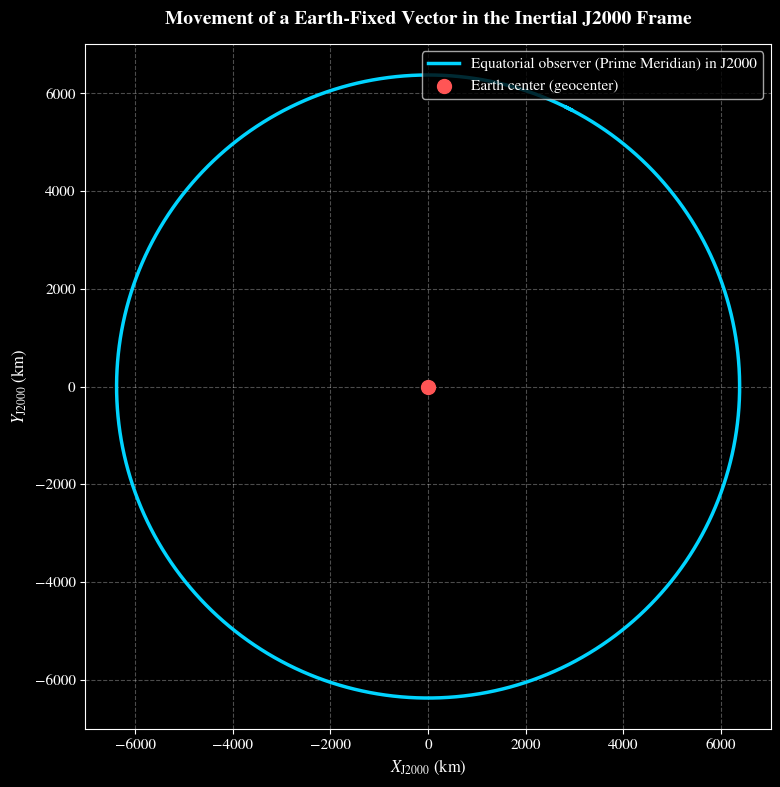

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(v_inertial_history[:, 0],
        v_inertial_history[:, 1],
        color='#00d4ff',
        linewidth=2.5,
        label="Equatorial observer (Prime Meridian) in J2000")

ax.scatter(0,
           0,
           color='#ff5555',
           s=100,
           zorder=5,
           label="Earth center (geocenter)")

ax.set_aspect('equal', 'box')
ax.set_xlabel(r"$X_{\mathrm{J2000}}$ (km)", fontsize=12)
ax.set_ylabel(r"$Y_{\mathrm{J2000}}$ (km)", fontsize=12)
ax.set_title("Movement of a Earth-Fixed Vector in the Inertial J2000 Frame", fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 3. Positional Astrodynamics: Sun-Centric Cartesian Coordinates in ECLIPJ2000

In astronomy, planetary orbits are often visualized to lie on the ecliptic plane. 
- **`ECLIPJ2000`** is an inertial reference frame that is mostly used w.r.t. the Sun as its center (or rather solar system barycenter depending on context/observer) where the $X$-$Y$ plane is explicitly aligned with the mean ecliptic of epoch `J2000`. 
- Unlike `J2000` (which is Earth equatorial-based and thus tilted by Earth's obliquity $\sim 23.4^\circ$), `ECLIPJ2000` aligns directly with Earth's orbital plane. Thus, Earth's $Z$ coordinate in `ECLIPJ2000` relative to the Sun is very close to zero!

Let's compute Earth's position relative to the Sun over an entire year (365.25 days) starting from May 25, 2026. To retrieve the position of one celestial body relative to another, we use:
`spice.spkpos(target, et, ref_frame, abcorr, observer)`

Where:
- `target`: `"EARTH"` (or `"399"`)
- `et`: Ephemeris Time (seconds past J2000)
- `ref_frame`: `"ECLIPJ2000"` (or `"J2000"` to compare obliquity)
- `abcorr`: Aberration correction - `"NONE"` for geometric orbits
- `observer`: `"SUN"` (or `"10"`)

In [11]:
# One full orbit (approx. 365.25 days)
days_in_year = np.linspace(0, 365.25, 1000)
ets_year = et_start + (days_in_year * 24.0 * 3600.0)

# Arrays to store positions
positions_eclip = []
positions_j2000 = []

for et in ets_year:
    # Get Earth position relative to the Sun (ECLIPJ2000 vs J2000)
    pos_eclip, _ = spice.spkpos("EARTH", et, "ECLIPJ2000", "NONE", "SUN")
    pos_j2000, _ = spice.spkpos("EARTH", et, "J2000", "NONE", "SUN")
    
    positions_eclip.append(pos_eclip)
    positions_j2000.append(pos_j2000)

positions_eclip = np.array(positions_eclip)
positions_j2000 = np.array(positions_j2000)

Let's visualize the orbits. First, we will plot the Earth's orbit in the $X$-$Y$ plane of `ECLIPJ2000` centered on the Sun. 
Second, we will plot the $Z$-coordinate (height above/below the respective plane) over time to show how Earth's orbit is perfectly flat in `ECLIPJ2000` (within numerical precision / small planetary perturbations), while in the equator-based `J2000` frame, it oscillates because of the $23.4^\circ$ obliquity of the Earth.

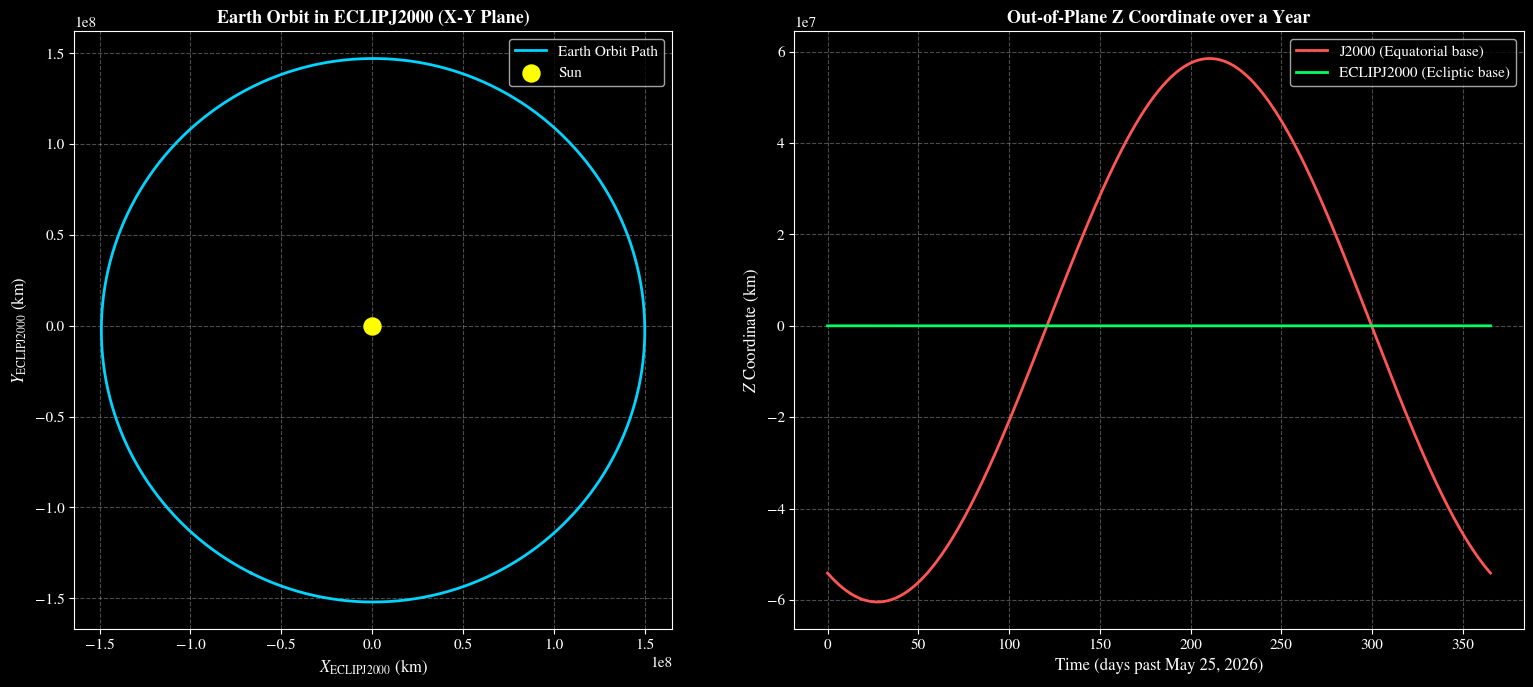

In [12]:
# Set up a side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: 2D Orbit in ECLIPJ2000
ax1.plot(positions_eclip[:, 0], positions_eclip[:, 1], color='#00d4ff', linewidth=2, label="Earth Orbit Path")
ax1.scatter(0, 0, color='yellow', s=150, label="Sun", zorder=5)
ax1.set_aspect('equal', 'box')
ax1.set_xlabel(r"$X_{\mathrm{ECLIPJ2000}}$ (km)", fontsize=12)
ax1.set_ylabel(r"$Y_{\mathrm{ECLIPJ2000}}$ (km)", fontsize=12)
ax1.set_title("Earth Orbit in ECLIPJ2000 (X-Y Plane)", fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend()

# Plot 2: Compare Z-coordinate (height out of plane) over time
ax2.plot(days_in_year, positions_j2000[:, 2], color='#ff5555', linewidth=2, label="J2000 (Equatorial base)")
ax2.plot(days_in_year, positions_eclip[:, 2], color='#00ff66', linewidth=2, label="ECLIPJ2000 (Ecliptic base)")
ax2.set_xlabel(r"Time (days past May 25, 2026)", fontsize=12)
ax2.set_ylabel(r"$Z$ Coordinate (km)", fontsize=12)
ax2.set_title("Out-of-Plane Z Coordinate over a Year", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend()

plt.tight_layout()
plt.show()